### Multi-Forecast by XGBoost Model

This project aim to forecast OHLC (Open, High, Low, Close) price utilising XGBoost model. Additionally, indicators such as EMA 10, 20, 50, 200, and MACD have been used as exogenous data.


### Libraries

In [665]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, mean_absolute_percentage_error
#randomized seach CV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
import random
import warnings
warnings.filterwarnings("ignore")

#### Load Data

In [706]:
df= yf.download('VIVO', period='max', interval='1d', multi_level_index=False)
df=df.reset_index()
#df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)
df.set_index('Date', inplace=True)
df=df.sort_index()
df.tail(1)

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-04-22,2.99,3.01,2.705,2.83,1994637


### Indicators

In [707]:
# Indicators
df['ema10'] = df.High.ewm(min_periods=10, span=10).mean()
df['ema12'] = df.Close.ewm(min_periods=12, span=12).mean()
df['ema20'] = df.Close.ewm(min_periods=20, span=20).mean()
df['ema26'] = df.Close.ewm(min_periods=26, span=26).mean()
df['ema50'] = df.Close.ewm(min_periods=50, span=50).mean()
df['ema200'] = df.Close.ewm(min_periods=200, span=200).mean()
df['MACD'] = df['ema26'] - df['ema12']
df['MACD_signal']=df.MACD.ewm(min_periods=9, span=9).mean()

### test and train split

In [708]:
df=df.dropna()
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

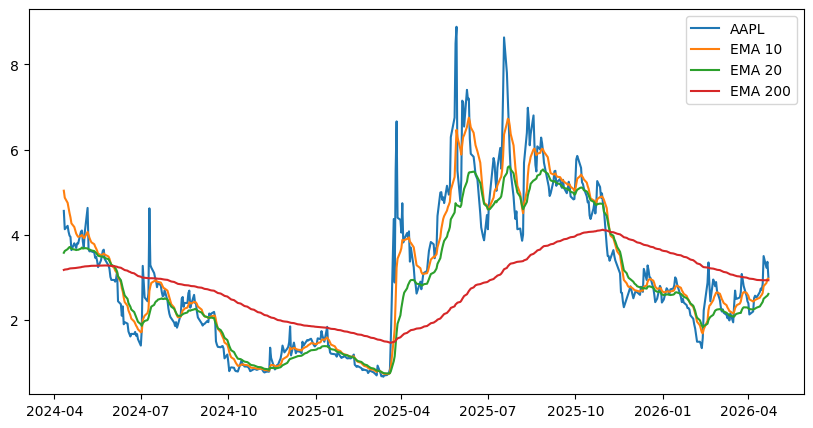

In [709]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test['High'], label= 'AAPL')
plt.plot(test.index, test['ema10'], label= 'EMA 10')
plt.plot(test.index, test['ema20'], label= 'EMA 20')
plt.plot(test.index, test['ema200'], label= 'EMA 200')
plt.legend()
plt.show()

### Feature Engineering

In [622]:
# target feature
target1='Open'
target2='High'
target3='Close'
target4='Low'

In [82]:
# exogenous variables
exogenous=['ema10','ema20','ema12','ema26','ema50','ema200','MACD','MACD_signal']

In [710]:
# test 1 and train 1
train1=train[[target1]]
test1=test[[target1]]
# test 2 and train 2
train2=train[[target2]]
test2=test[[target2]]
# test 3 and train 3
train3=train[[target3]]
test3=test[[target3]]
# test 4 and train 4
train4=train[[target4]]
test4=test[[target4]]

### Making lags features

In [625]:
def make_lags(data):
    for col in data:
        for lag in range(1,31):
            data[f'{col}_lag{lag}']=data[col].shift(lag)
    return data

In [711]:
# Lags for target 1
train1= make_lags(train1).dropna()
test1=make_lags(test1).dropna()
# Lags for target 2
train2= make_lags(train2).dropna()
test2=make_lags(test2).dropna()
# Lags for target 3
train3= make_lags(train3).dropna()
test3=make_lags(test3).dropna()
# Lags for target 4
train4= make_lags(train4).dropna()
test4=make_lags(test4).dropna()

### X_train and y_train

In [712]:
# X_train, X_test, y_train, y_test for target 1
X_train1, y_train1 = train1.iloc[:,1:],train1[target1]
X_test1, y_test1 = test1.iloc[:,1:], test1[target1]
# X_train, X_test, y_train, y_test for target 2
X_train2, y_train2 = train2.iloc[:,1:],train2[target2]
X_test2, y_test2 = test2.iloc[:,1:], test2[target2]
# X_train, X_test, y_train, y_test for target 3
X_train3, y_train3 = train3.iloc[:,1:],train3[target3]
X_test3, y_test3 = test3.iloc[:,1:], test3[target3]
# X_train, X_test, y_train, y_test for target 4
X_train4, y_train4 = train4.iloc[:,1:],train4[target4]
X_test4, y_test4 = test4.iloc[:,1:], test4[target4]

### XGBoost Models with Best Parameters

### Best Parameters

In [666]:
#range of parameters
param_range = {
    'n_estimators': randint(100, 2000),
    "learning_rate": loguniform(0.001, 0.3),
    'max_depth': randint(3, 12),
    "gamma": loguniform(1e-8, 10),
    "min_child_weight": loguniform(0.01, 20),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    "colsample_bylevel": uniform(0.5, 0.5),
    "colsample_bynode": uniform(0.5, 0.5),
    "reg_alpha": loguniform(1e-8, 10),                 
    "reg_lambda": loguniform(1e-8, 10),
    "max_bin": randint(128, 512),
    "grow_policy": ["depthwise", "lossguide"],
    "max_leaves": randint(0, 256),
    "tree_method": ["gpu_hist"],
}

In [667]:
model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [669]:
#RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_range,
    n_iter=60,                    
    scoring="neg_root_mean_squared_error", 
    cv=5,
    verbose=3,
    n_jobs=-1
)

In [670]:
search.fit(X_train1,y_train1)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bylevel': <scipy.stats....001ED1995D010>, 'colsample_bynode': <scipy.stats....001ED1995CBC0>, 'colsample_bytree': <scipy.stats....001ED1A1E1400>, 'gamma': <scipy.stats....001ED1A173B30>, ...}"
,n_iter,60
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [671]:
search.best_params_

{'colsample_bylevel': np.float64(0.97376265393625),
 'colsample_bynode': np.float64(0.677528347550434),
 'colsample_bytree': np.float64(0.8608947044026214),
 'gamma': np.float64(6.847185865367803e-08),
 'grow_policy': 'lossguide',
 'learning_rate': np.float64(0.1269589234594256),
 'max_bin': 432,
 'max_depth': 8,
 'max_leaves': 14,
 'min_child_weight': np.float64(0.15378866439636615),
 'n_estimators': 1019,
 'reg_alpha': np.float64(0.001543482262812263),
 'reg_lambda': np.float64(2.2061958334299833e-05),
 'subsample': np.float64(0.9788227798622239),
 'tree_method': 'gpu_hist'}

#### Independent Models for each regressor

In [722]:
model_b1 = XGBRegressor(objective='reg:squarederror',random_state=42,
colsample_bylevel= np.float64(0.97376265393625),
 colsample_bynode=np.float64(0.677528347550434),
 colsample_bytree= np.float64(0.8608947044026214),
 gamma= np.float64(6.847185865367803e-08),
 grow_policy= 'lossguide',
 learning_rate= np.float64(0.1269589234594256),
 max_bin= 432,
 max_depth=8,
 max_leaves= 14,
 min_child_weight= np.float64(0.15378866439636615),
 n_estimators= 1019,
 reg_alpha= np.float64(0.001543482262812263),
 reg_lambda= np.float64(2.2061958334299833e-05),
 subsample= np.float64(0.9788227798622239),
tree_method='gpu_hist')

model_b2 = XGBRegressor(objective='reg:squarederror',random_state=42,
colsample_bylevel= np.float64(0.97376265393625),
 colsample_bynode=np.float64(0.677528347550434),
 colsample_bytree= np.float64(0.8608947044026214),
 gamma= np.float64(6.847185865367803e-08),
 grow_policy= 'lossguide',
 learning_rate= np.float64(0.1269589234594256),
 max_bin= 432,
 max_depth=8,
 max_leaves= 14,
 min_child_weight= np.float64(0.15378866439636615),
 n_estimators= 1019,
 reg_alpha= np.float64(0.001543482262812263),
 reg_lambda= np.float64(2.2061958334299833e-05),
 subsample= np.float64(0.9788227798622239),
tree_method='gpu_hist')

model_b3 = XGBRegressor(objective='reg:squarederror',random_state=42,
colsample_bylevel= np.float64(0.97376265393625),
 colsample_bynode=np.float64(0.677528347550434),
 colsample_bytree= np.float64(0.8608947044026214),
 gamma= np.float64(6.847185865367803e-08),
 grow_policy= 'lossguide',
 learning_rate= np.float64(0.1269589234594256),
 max_bin= 432,
 max_depth=8,
 max_leaves= 14,
 min_child_weight= np.float64(0.15378866439636615),
 n_estimators= 1019,
 reg_alpha= np.float64(0.001543482262812263),
 reg_lambda= np.float64(2.2061958334299833e-05),
 subsample= np.float64(0.9788227798622239),
tree_method='gpu_hist')

model_b4 = XGBRegressor(objective='reg:squarederror',random_state=42,
colsample_bylevel= np.float64(0.97376265393625),
 colsample_bynode=np.float64(0.677528347550434),
 colsample_bytree= np.float64(0.8608947044026214),
 gamma= np.float64(6.847185865367803e-08),
 grow_policy= 'lossguide',
 learning_rate= np.float64(0.1269589234594256),
 max_bin= 432,
 max_depth=8,
 max_leaves= 14,
 min_child_weight= np.float64(0.15378866439636615),
 n_estimators= 1019,
 reg_alpha= np.float64(0.001543482262812263),
 reg_lambda= np.float64(2.2061958334299833e-05),
 subsample= np.float64(0.9788227798622239),
tree_method='gpu_hist')

In [723]:
model_b1.fit(X_train1,y_train1)
model_b2.fit(X_train2,y_train2)
model_b3.fit(X_train3,y_train3)
model_b4.fit(X_train4,y_train4)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,np.float64(0.97376265393625)
,colsample_bynode,np.float64(0.677528347550434)
,colsample_bytree,np.float64(0.8608947044026214)
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Predict

In [725]:
pred1 = model_b1.predict(X_test1)
pred2 = model_b2.predict(X_test2)
pred3 = model_b3.predict(X_test3)
pred4 = model_b4.predict(X_test4)

### Accuracy Predicted vs Actual

In [579]:
def evaluate_predictions(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"--- {label} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}")
    print()

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "mape": mape
    }

In [726]:
metrics_open = evaluate_predictions(test1[target1], pred1, "Open")
metrics_high = evaluate_predictions(test2[target2], pred2, "High")
metrics_close = evaluate_predictions(test3[target3], pred3, "Close")
metrics_close = evaluate_predictions(test4[target4], pred4, "Low")

--- Open ---
RMSE: 0.6508
MAE: 0.4690
R² Score: 0.8377
MAPE: 0.2561

--- High ---
RMSE: 0.6393
MAE: 0.4573
R² Score: 0.8661
MAPE: 0.2125

--- Close ---
RMSE: 0.4741
MAE: 0.3430
R² Score: 0.9108
MAPE: 0.1748

--- Low ---
RMSE: 0.4950
MAE: 0.3558
R² Score: 0.8900
MAPE: 0.1842



### Checking for overfitting

In [727]:
# Model 1
train_pred1 = model_b1.predict(X_train1)
test_pred1 = model_b1.predict(X_test1)
# Model 2
train_pred2 = model_b2.predict(X_train2)
test_pred2 = model_b2.predict(X_test2)
# Model 3
train_pred3 = model_b3.predict(X_train3)
test_pred3 = model_b3.predict(X_test3)
# Model 4
train_pred4 = model_b4.predict(X_train4)
test_pred4 = model_b4.predict(X_test4)

In [728]:
train_metrics_model1 = evaluate_predictions(train1[target1], train_pred1,'Train Model 1')
test_metrics_model1 = evaluate_predictions(test1[target1], test_pred1, 'Test Model 1')

train_metrics_model2 = evaluate_predictions(train2[target2], train_pred2,'Train Model 2')
test_metrics_model2 = evaluate_predictions(test2[target2], test_pred2, 'Test Model 2')

train_metrics_model3 = evaluate_predictions(train3[target3], train_pred3,'Train Model 3')
test_metrics_model3 = evaluate_predictions(test3[target3], test_pred3, 'Test Model 3')

train_metrics_model4 = evaluate_predictions(train4[target4], train_pred4,'Train Model 4')
test_metrics_model4 = evaluate_predictions(test4[target4], test_pred4, 'Test Model 4')


--- Train Model 1 ---
RMSE: 0.0361
MAE: 0.0284
R² Score: 1.0000
MAPE: 0.0024

--- Test Model 1 ---
RMSE: 0.6508
MAE: 0.4690
R² Score: 0.8377
MAPE: 0.2561

--- Train Model 2 ---
RMSE: 0.0468
MAE: 0.0359
R² Score: 1.0000
MAPE: 0.0028

--- Test Model 2 ---
RMSE: 0.6393
MAE: 0.4573
R² Score: 0.8661
MAPE: 0.2125

--- Train Model 3 ---
RMSE: 0.0375
MAE: 0.0291
R² Score: 1.0000
MAPE: 0.0025

--- Test Model 3 ---
RMSE: 0.4741
MAE: 0.3430
R² Score: 0.9108
MAPE: 0.1748

--- Train Model 4 ---
RMSE: 0.0333
MAE: 0.0260
R² Score: 1.0000
MAPE: 0.0023

--- Test Model 4 ---
RMSE: 0.4950
MAE: 0.3558
R² Score: 0.8900
MAPE: 0.1842



### Comparison of Train and Test 

In [293]:
def overfitting_check(train_metrics, test_metrics,label=''):
    print(f'--- {label} ---')

    for metric in ['rmse','mae','r2','mape']:
        train= train_metrics[metric]
        test= test_metrics[metric]

        if metric == 'r2':
            diff = train - test
        else:
            diff = test - train
        print(f'{metric.upper()}: Train={train: .4f} | Test ={test:.4f} | Gap= {diff:.4f}')
    print()

In [729]:
overfitting_check(train_metrics_model1, test_metrics_model1, 'Model 1 (Open)')
overfitting_check(train_metrics_model2, test_metrics_model2, 'Model 2 (High)')
overfitting_check(train_metrics_model3, test_metrics_model3, 'Model 3 (Close)')
overfitting_check(train_metrics_model4, test_metrics_model4, 'Model 4 (Low)')

--- Model 1 (Open) ---
RMSE: Train= 0.0361 | Test =0.6508 | Gap= 0.6146
MAE: Train= 0.0284 | Test =0.4690 | Gap= 0.4406
R2: Train= 1.0000 | Test =0.8377 | Gap= 0.1623
MAPE: Train= 0.0024 | Test =0.2561 | Gap= 0.2537

--- Model 2 (High) ---
RMSE: Train= 0.0468 | Test =0.6393 | Gap= 0.5925
MAE: Train= 0.0359 | Test =0.4573 | Gap= 0.4214
R2: Train= 1.0000 | Test =0.8661 | Gap= 0.1339
MAPE: Train= 0.0028 | Test =0.2125 | Gap= 0.2097

--- Model 3 (Close) ---
RMSE: Train= 0.0375 | Test =0.4741 | Gap= 0.4367
MAE: Train= 0.0291 | Test =0.3430 | Gap= 0.3138
R2: Train= 1.0000 | Test =0.9108 | Gap= 0.0892
MAPE: Train= 0.0025 | Test =0.1748 | Gap= 0.1723

--- Model 4 (Low) ---
RMSE: Train= 0.0333 | Test =0.4950 | Gap= 0.4617
MAE: Train= 0.0260 | Test =0.3558 | Gap= 0.3298
R2: Train= 1.0000 | Test =0.8900 | Gap= 0.1100
MAPE: Train= 0.0023 | Test =0.1842 | Gap= 0.1819



### Predicted vs Actual Plot

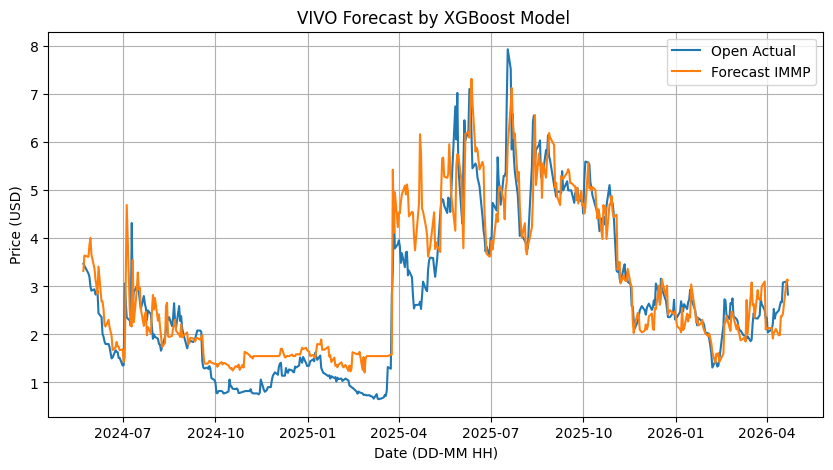

In [730]:
plt.figure(figsize= (10,5))
plt.plot(test1.index, test1[target1], label=f'{target1} Actual')
plt.plot(test1.index, pred1, label = 'Forecast IMMP')
plt.title('VIVO Forecast by XGBoost Model ')
plt.xlabel('Date (DD-MM HH)')
plt.ylabel('Price (USD)')
plt.grid()
plt.legend()
plt.show()

### Feature importance

<Axes: >

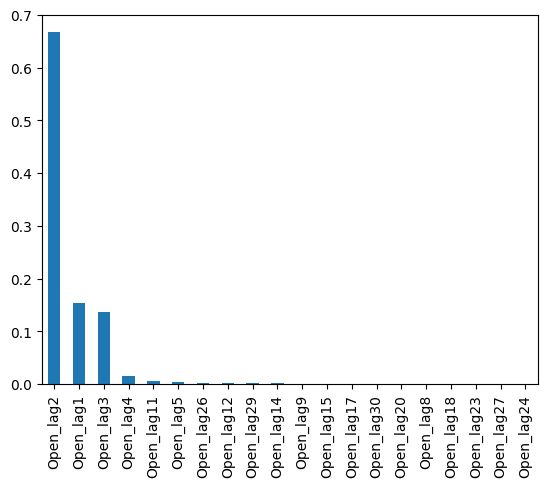

In [734]:
#feature importcance
importance= model_b1.feature_importances_
f_imp =pd.Series(importance, index= X_train.columns).sort_values(ascending=False)
f_imp.head(20).plot(kind='bar')

### Residuals

Text(0.5, 1.0, 'Distribution of residuals')

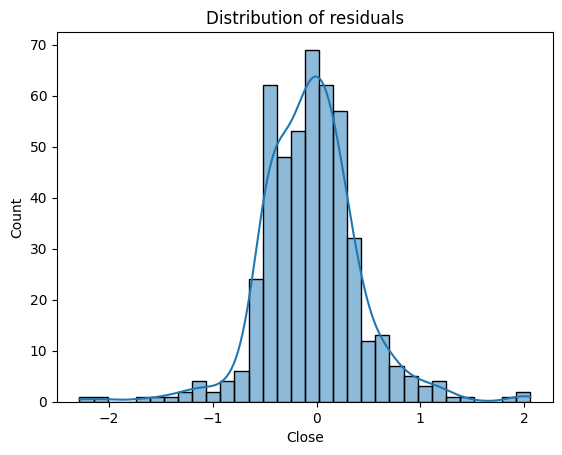

In [737]:
#residuals
residuals= y_test3 - pred3
sns.histplot(residuals, kde=True)
plt.title('Distribution of residuals')

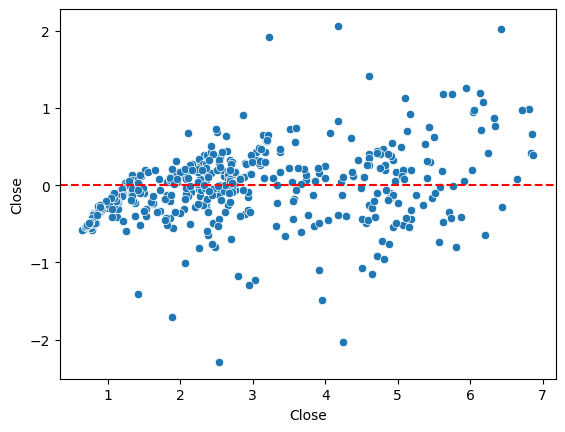

In [738]:
sns.scatterplot(x=y_test3, y=residuals)
plt.axhline(0,color='red', linestyle='--')
plt.show()

### Forecast 1 Day ahead

In [752]:
test1.tail(1)

,Open,Open_lag1,Open_lag2,Open_lag3,Open_lag4,Open_lag5,Open_lag6,Open_lag7,Open_lag8,Open_lag9,...,Open_lag21,Open_lag22,Open_lag23,Open_lag24,Open_lag25,Open_lag26,Open_lag27,Open_lag28,Open_lag29,Open_lag30
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-22,2.83,3.1,3.1,3.08,2.67,2.68,2.6,2.5,2.43,2.33,...,2.33,2.34,2.44,2.23,1.89,1.86,1.96,1.91,1.96,1.98


In [774]:
def get_next_day(X, target_col=''):
    last_row= X.iloc[-1].copy()

    new_row ={}

    for i in range(1,31):
        new_row[f'{target_col}_lag{i}'] = last_row[f'{target_col}_lag{i}']

    new_row[f'{target_col}_lag1'] = last_row[target_col]

    new_row_df = pd.DataFrame([new_row])

    new_time = X.index[-1] + pd.Timedelta(days=1)
    new_row_df.index = [new_time]

    return new_row_df

In [775]:
next_row1 = get_next_day(test1,target_col=target1)
next_row2 = get_next_day(test2,target_col=target2)
next_row3 = get_next_day(test3,target_col=target3)
next_row4 = get_next_day(test4,target_col=target4)

In [776]:
next_row1

,Open_lag1,Open_lag2,Open_lag3,Open_lag4,Open_lag5,Open_lag6,Open_lag7,Open_lag8,Open_lag9,Open_lag10,...,Open_lag21,Open_lag22,Open_lag23,Open_lag24,Open_lag25,Open_lag26,Open_lag27,Open_lag28,Open_lag29,Open_lag30
2026-04-23,2.83,3.1,3.08,2.67,2.68,2.6,2.5,2.43,2.33,2.53,...,2.33,2.34,2.44,2.23,1.89,1.86,1.96,1.91,1.96,1.98


In [777]:
predicted1=model_b1.predict(next_row1)
predicted2=model_b2.predict(next_row2)
predicted3=model_b3.predict(next_row3)
predicted4=model_b4.predict(next_row4)

#### Prediction

In [778]:
print(f"{next_row1.index[0]} {target1} Prediction: {predicted1[0]}")
print(f"{next_row2.index[0]} {target2} Prediction: {predicted2[0]}")
print(f"{next_row3.index[0]} {target3} Prediction: {predicted3[0]}")
print(f"{next_row4.index[0]} {target4} Prediction: {predicted4[0]}")


2026-04-23 00:00:00 Open Prediction: 2.559255599975586
2026-04-23 00:00:00 High Prediction: 2.9108123779296875
2026-04-23 00:00:00 Close Prediction: 2.6926651000976562
2026-04-23 00:00:00 Low Prediction: 2.6264266967773438


### Prediction Plot

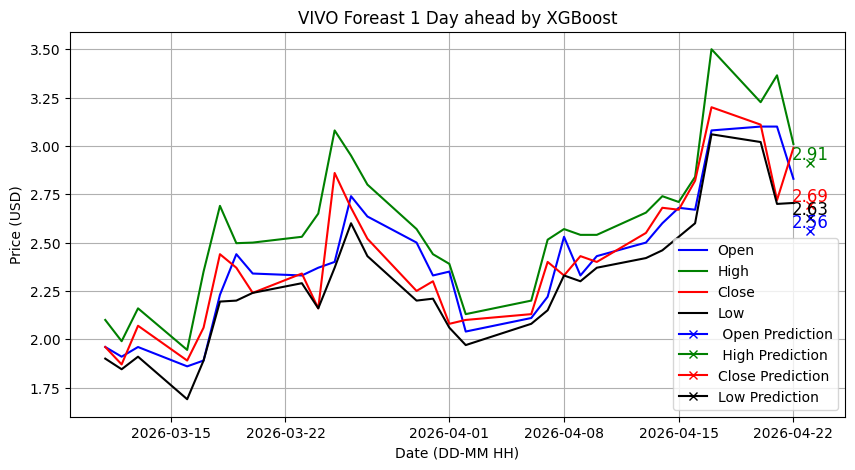

In [779]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
#plt.plot(test1.index[-30:], pred[-30:], label='Forecasted Data')
plt.plot(test1.index[-30:], test1[target1][-30:], label=target1,color='blue')
plt.plot(test2.index[-30:], test2[target2][-30:], label=target2,color='green')
plt.plot(test3.index[-30:], test3[target3][-30:], label=target3,color='red')
plt.plot(test4.index[-30:], test4[target4][-30:], label=target4,color='black')
plt.plot(next_row1.index, predicted1, label=' Open Prediction', marker='x',color='blue')
plt.plot(next_row2.index, predicted2, label=' High Prediction', marker='x',color='green')
plt.plot(next_row3.index, predicted3, label='Close Prediction', marker='x',color='red')
plt.plot(next_row4.index, predicted4, label='Low Prediction', marker='x',color='black')
plt.text(next_row1.index, predicted1, f"{predicted1[0]:.2f}",color='blue', fontsize=12,ha='center', va='bottom')
plt.text(next_row2.index, predicted2, f"{predicted2[0]:.2f}",color='green', fontsize=12,ha='center', va='bottom')
plt.text(next_row3.index, predicted3, f"{predicted3[0]:.2f}",color='red', fontsize=12,ha='center', va='bottom')
plt.text(next_row3.index, predicted4, f"{predicted4[0]:.2f}",color='black', fontsize=12,ha='center', va='bottom')
plt.title('VIVO Foreast 1 Day ahead by XGBoost')
plt.xlabel('Date (DD-MM HH)')
plt.ylabel('Price (USD)')
plt.grid()
plt.legend()
plt.show()